In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.geoaxes import GeoAxes
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [3]:
from xmip.preprocessing import combined_preprocessing
import regionmask
from xmip.regionmask import merged_mask
import warnings
import matplotlib.pyplot as plt
import numpy as np
import glob
import xarray as xr
import xbudget
import regionate
import xwmt
import xwmb
import xgcm
import matplotlib.colors as mcolors
import cmocean
import cartopy.crs as ccrs
from scipy.interpolate import PchipInterpolator
# import CM4Xutils #needed to run pip install nc-time-axis
# from regionate import MaskRegions, GriddedRegion
import sys
sys.path.insert(0, '/user/anthony.meza/CM4XAbyssalSWMT/src')
from src import *
import matplotlib as mpl
import seaborn as sns
sns.set_theme(context='notebook', style='ticks')
mpl.rcParams['figure.dpi'] = 150

### Request HPC Resources

In [4]:
from dask_jobqueue import SLURMCluster  # setup dask cluster 
from dask.distributed import Client

log_directory="/user/anthony.meza/CM4XAbyssalSWMT/notebooks/logs"

cluster = SLURMCluster(
    cores=36,
    processes=1,
    memory='190GB',
    walltime='03:00:00',
    queue='scavenger',
log_directory = log_directory)
print(cluster.job_script())
cluster.scale(jobs=16)

client = Client(cluster)
client

#!/usr/bin/env bash

#SBATCH -J dask-worker
#SBATCH -e /user/anthony.meza/CM4XAbyssalSWMT/notebooks/logs/dask-worker-%J.err
#SBATCH -o /user/anthony.meza/CM4XAbyssalSWMT/notebooks/logs/dask-worker-%J.out
#SBATCH -p scavenger
#SBATCH -n 1
#SBATCH --cpus-per-task=36
#SBATCH --mem=177G
#SBATCH -t 03:00:00

/user/anthony.meza/miniforge3/envs/cm4x_chapter2/bin/python -m distributed.cli.dask_worker tcp://10.151.1.152:34213 --name dummy-name --nthreads 36 --memory-limit 176.95GiB --nanny --death-timeout 60



Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://10.151.1.152:34213,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [5]:
native_path = datadir("transient_tracers_z")
files = ["CM4Xp125_piControl_transient_tracers_z.zarr", "CM4Xp125_historical_transient_tracers_z.zarr", "CM4Xp125_ssp585_transient_tracers_z.zarr"]
full_depth_files = [native_path + "/" + a for a in files]

files = ["CM4Xp125_piControl_transient_tracers_surface.zarr", 
         "CM4Xp125_historical_transient_tracers_surface.zarr", 
         "CM4Xp125_ssp585_transient_tracers_surface.zarr"]
surface_files = [native_path + "/" + a for a in files]

In [6]:
def preprocess(ds):
    if ("year_ctrl" in ds.coords) or ("time_ctrl" in ds.coords):
        # if "time_ctrl" in ds.coords:
        #     ds = ds.reset_coords("year_ctrl", drop=True)
        # else:
        #     ds = ds.reset_coords("time_ctrl", drop=True)
        ds = ds.expand_dims(expt=["control"])
        ds.coords["year"] = ds.coords["year"]
        ds = ds.drop_vars(["year_ctrl"])
    else: 
        ds = ds.expand_dims(expt=["forced"])        
    return ds.isel(yh = slice(0, 150)).sel(year = slice(None, 2099))
ds_ctrl= xr.open_mfdataset(full_depth_files[0], combine="nested", concat_dim=["year"], parallel=True, preprocess=preprocess, engine = "zarr")
ds_forced = xr.open_mfdataset(full_depth_files[1:], combine="nested", concat_dim=["year"], parallel=True, preprocess=preprocess, engine = "zarr")

ds= xr.concat([ds_ctrl, ds_forced], dim = "expt")

In [7]:
z_i = np.array([0.000e+00, 5.000e+00, 1.500e+01, 2.500e+01, 4.000e+01, 6.250e+01,
       8.750e+01, 1.125e+02, 1.375e+02, 1.750e+02, 2.250e+02, 2.750e+02,
       3.500e+02, 4.500e+02, 5.500e+02, 6.500e+02, 7.500e+02, 8.500e+02,
       9.500e+02, 1.050e+03, 1.150e+03, 1.250e+03, 1.350e+03, 1.450e+03,
       1.625e+03, 1.875e+03, 2.250e+03, 2.750e+03, 3.250e+03, 3.750e+03,
       4.250e+03, 4.750e+03, 5.250e+03, 5.750e+03, 6.250e+03, 6.750e+03])
ds = ds.assign_coords({"z_i":z_i})

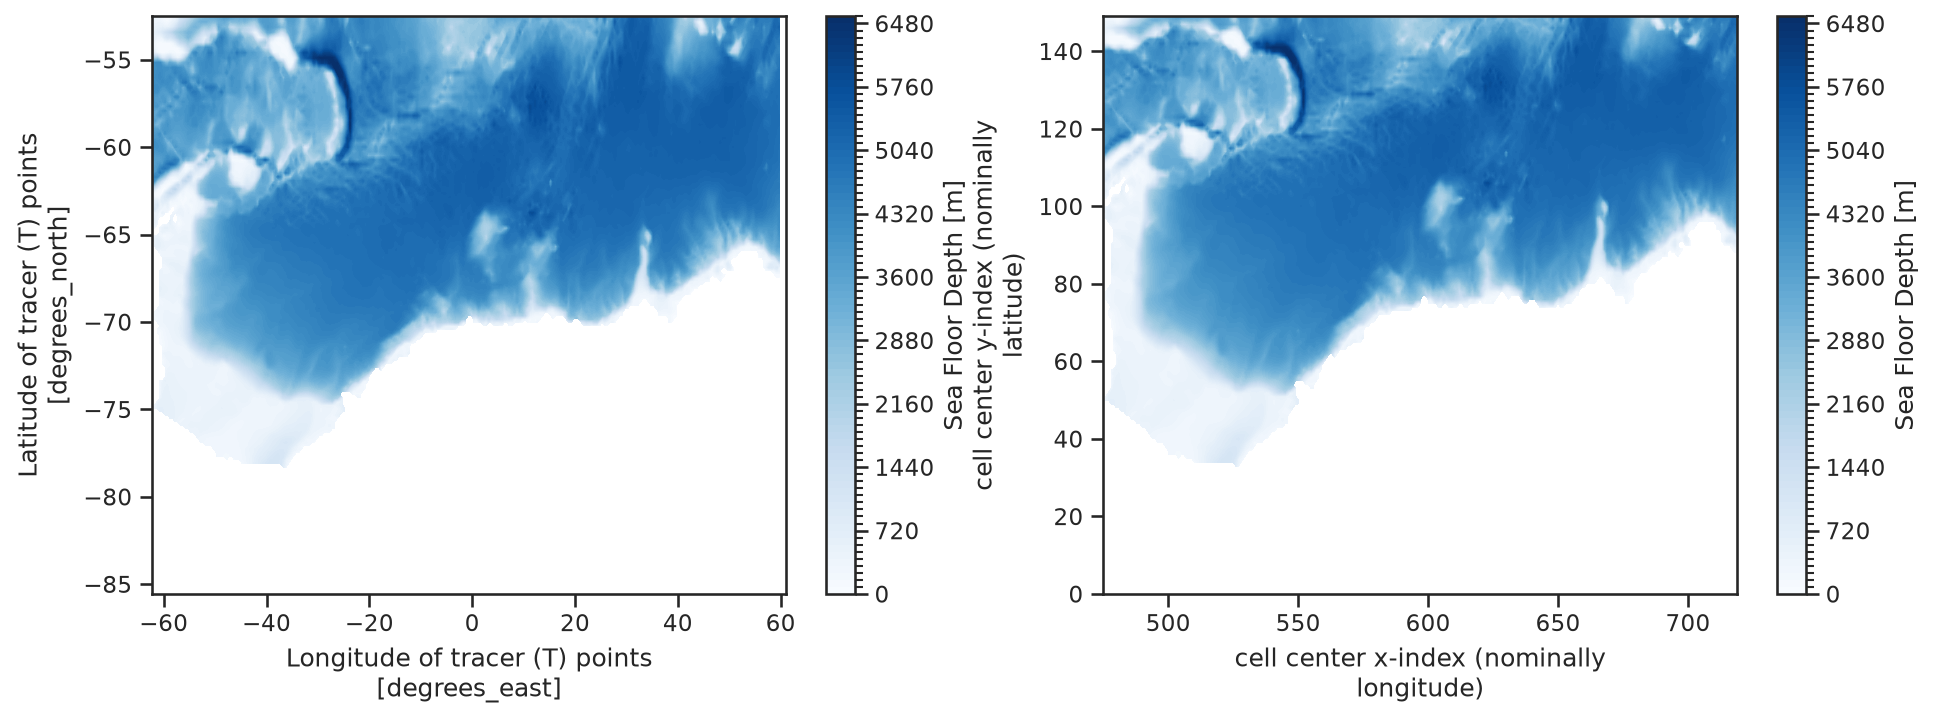

In [8]:
fig, ax = plt.subplots(1,2, figsize = (15, 5))
ds_subset = ds.isel(xh = slice(475, None))
bottom_subset = ds_subset.ffill("z_l").isel(z_l = -1)
ds_subset.deptho.plot.contourf(ax = ax[0], x = "geolon", y = "geolat", cmap = "Blues", levels = 100)
ds_subset.deptho.plot.contourf(ax = ax[1], cmap = "Blues", levels = 100)

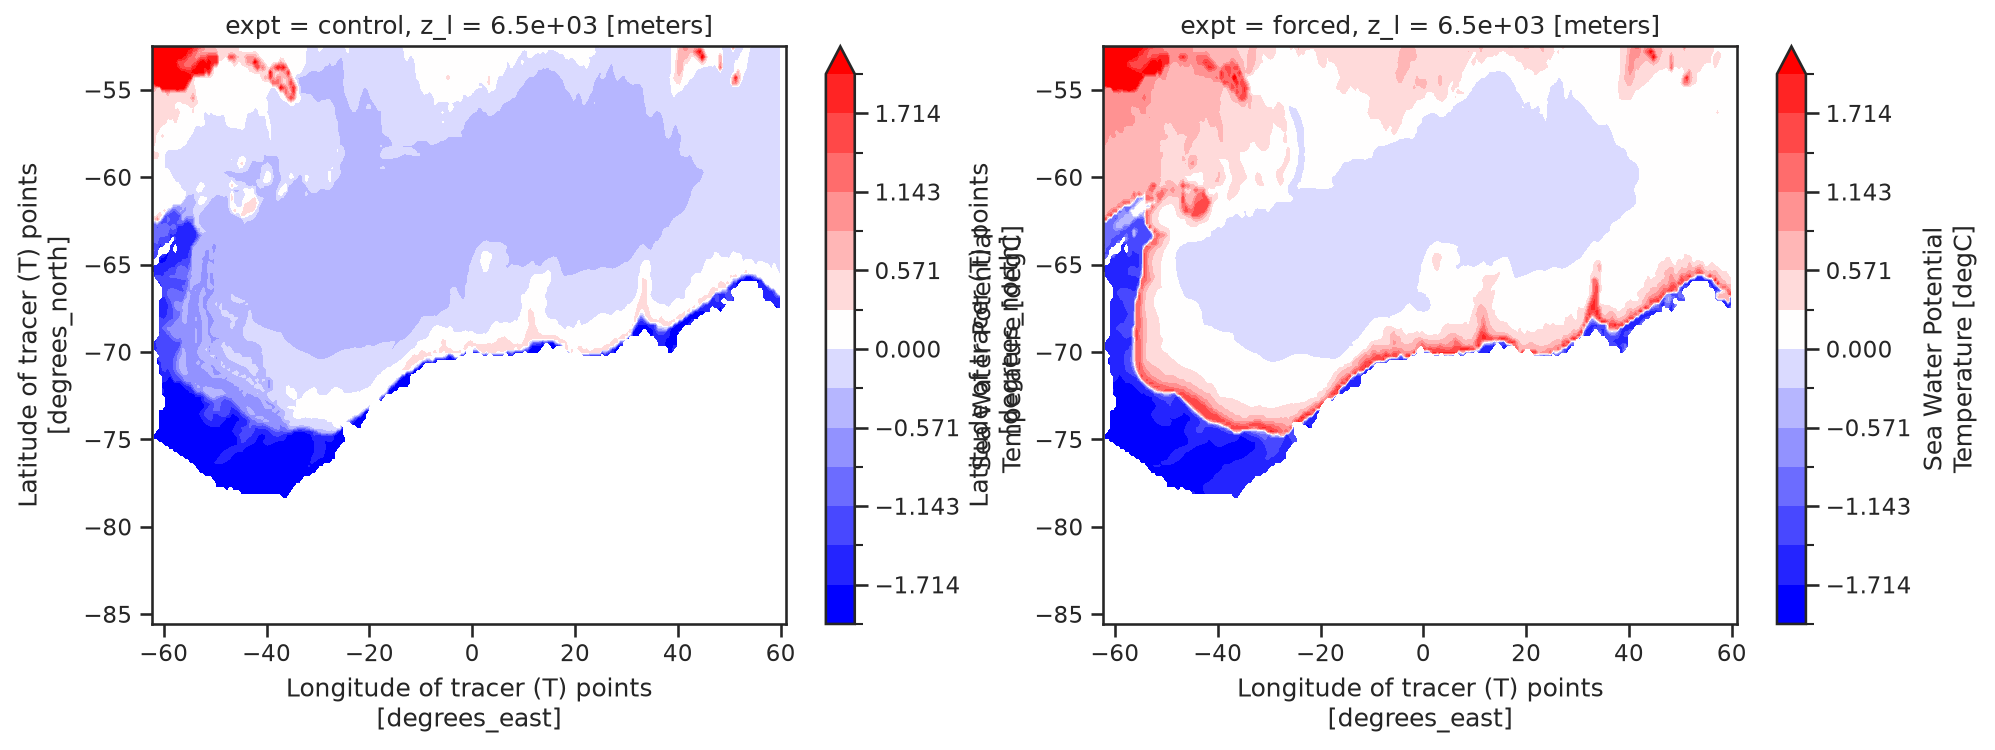

In [9]:
fig, ax = plt.subplots(1,2, figsize = (15, 5))
bottom_temp = bottom_subset.thetao.isel(year = slice(-50, None)).mean("year")
vmin = -2
vmax = 2

levels = np.linspace(vmin, vmax, 15)
bottom_temp.isel(expt = 0).plot.contourf(ax = ax[0], x = "geolon", y = "geolat", 
                                       vmin = vmin, vmax = vmax, levels = levels, 
                                      cmap = "bwr")
bottom_temp.isel(expt = 1).plot.contourf(ax = ax[1], x = "geolon", y = "geolat", 
                                       vmin = vmin, vmax = vmax, levels = levels, 
                                      cmap = "bwr")

In [10]:
import numpy as np
from pyproj import Geod
from scipy.interpolate import interpn

spacing_km = 5

# lat_tie = np.asarray([-73, -70, -67, -64.5, -63., -62.4, -62.2, -62.2])
# lon_tie = np.asarray([-55, -54.1, -53.5, -52, -46.5, -41, -36, -30])

lat_tie = np.asarray([-73, -70, -67, -64.5, -63., -62.4,])
lon_tie = np.asarray([-55, -54.1, -53.5, -52, -46.5, -41])

geod = Geod(ellps="WGS84")

_, _, d_s = geod.inv(
    lon_tie[:-1],
    lat_tie[:-1],
    lon_tie[1:],
    lat_tie[1:],
)

s_tie = np.concatenate([[0], np.cumsum(d_s) / 1000])  # km

s = np.arange(0, s_tie[-1] + spacing_km, spacing_km)

lon_points = np.interp(s, s_tie, lon_tie)
lat_points = np.interp(s, s_tie, lat_tie)

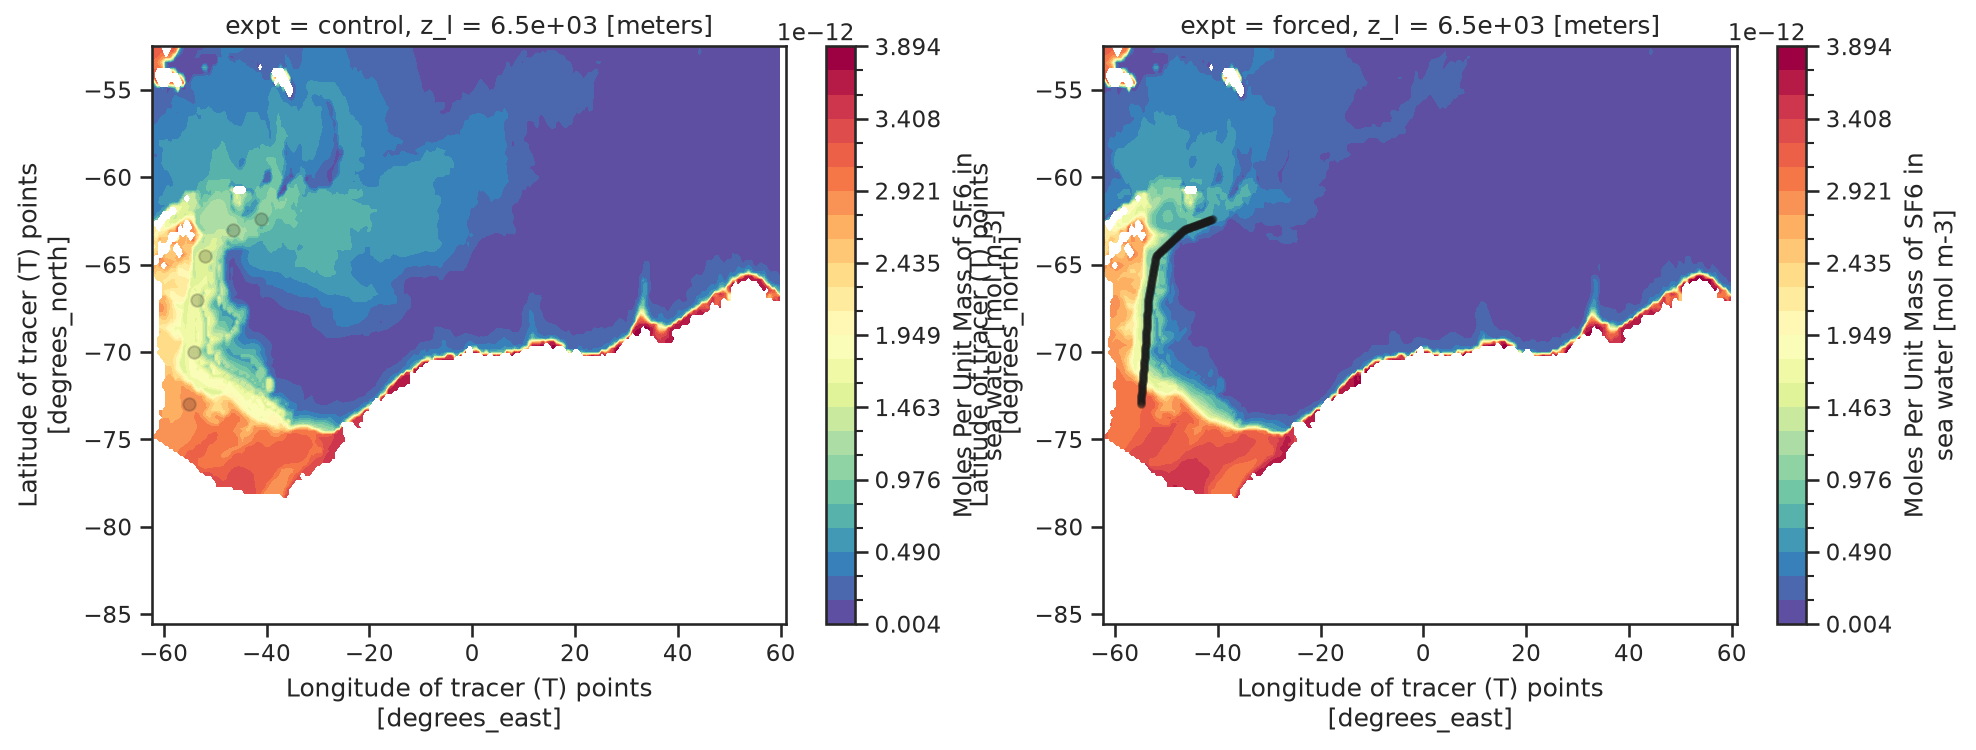

In [11]:
fig, ax = plt.subplots(1,2, figsize = (15, 5))

bottom_sf6 = bottom_subset.sf6
bottom_sf6 = bottom_sf6.where(bottom_subset.deptho > 200).sel(year = slice(2015, 2025)).mean("year")
vmin = bottom_sf6.min().compute().values
vmax = bottom_sf6.max().compute().values

levels = np.linspace(vmin, vmax, 25)
bottom_sf6.isel(expt = 0).plot.contourf(ax = ax[0], x = "geolon", y = "geolat", 
                                       vmin = vmin, vmax = vmax, levels = levels, 
                                      cmap = "Spectral_r")
ax[0].scatter(lon_tie, lat_tie, alpha = 0.2, c = "k")

# ax[0].scatter(lon_points, lat_points, alpha = 0.2, c = "k")
bottom_sf6.isel(expt = 1).plot.contourf(ax = ax[1], x = "geolon", y = "geolat", 
                                       vmin = vmin, vmax = vmax, levels = levels, 
                                      cmap = "Spectral_r")
ax[1].scatter(lon_points, lat_points, alpha = 0.2, c = "k", s = 10)


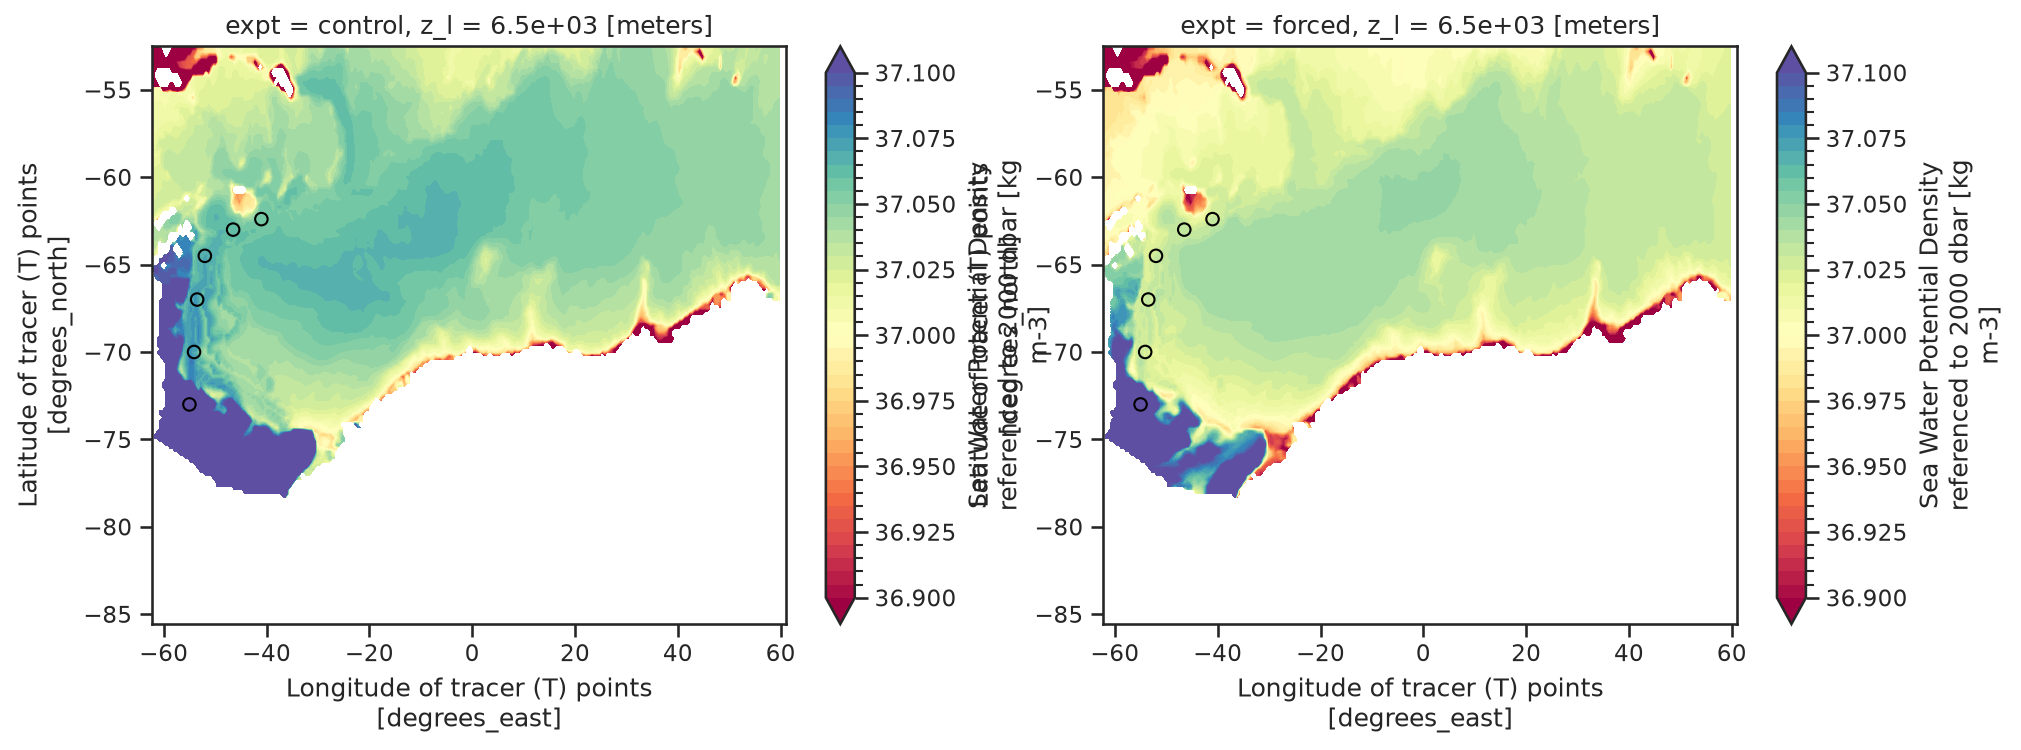

In [12]:
fig, ax = plt.subplots(1,2, figsize = (15, 5))

bottom_density = bottom_subset.sigma2_offline
bottom_density = bottom_density.where(bottom_subset.deptho > 200).sel(year = slice(2015, 2025)).mean("year")

levels =  np.arange(36.9, 37.1 + 1e-16, 0.005)
bottom_density.isel(expt = 0).plot.contourf(ax = ax[0], x = "geolon", y = "geolat", 
                                       vmin = vmin, vmax = vmax, levels = levels, 
                                      cmap = "Spectral")
ax[0].scatter(lon_tie, lat_tie, facecolors='none', edgecolors='black')
bottom_density.isel(expt = 1).plot.contourf(ax = ax[1], x = "geolon", y = "geolat", 
                                       vmin = vmin, vmax = vmax, levels = levels, 
                                      cmap = "Spectral")
ax[1].scatter(lon_tie, lat_tie, facecolors='none', edgecolors='black')


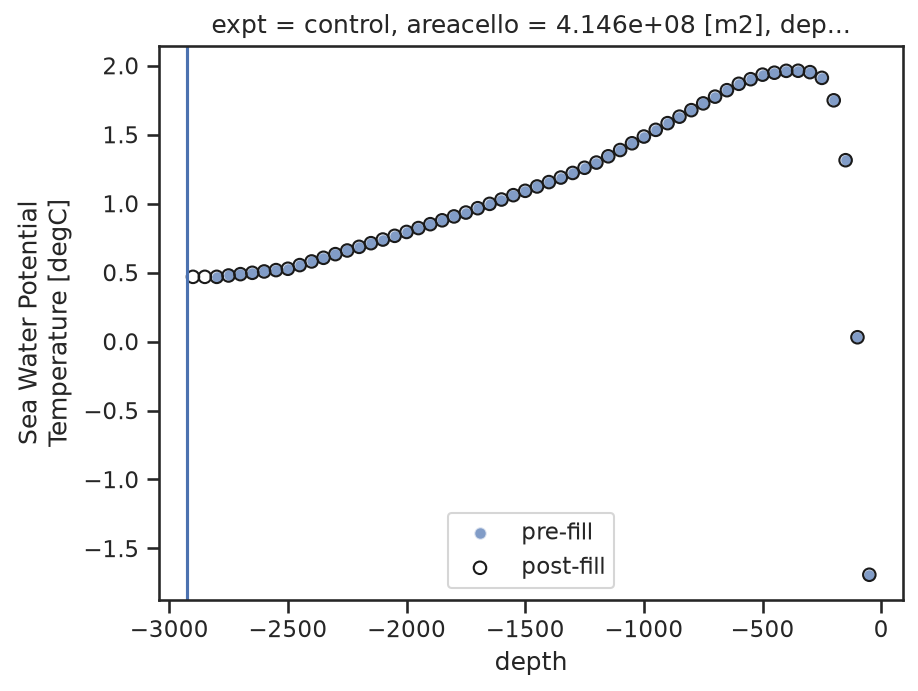

In [13]:
rename_geocoords = lambda ds: ds.rename({"lat":"old_lat", "lon":"old_lon"}).rename({"geolat":"lat", "geolon":"lon"})
grid = Grid(ds, coords={"Z": {"center": "z_l"}}, periodic=False, autoparse_metadata=False)

ds_filtered = ds.where(ds.thkcello.fillna(0.0) > 0.0)
ds_filtered["depth"] = approximate_z_top_down(ds, dim="z")
ds_filtered = ds_filtered.chunk({"z_l":-1})
depth_target = np.arange(-5500.0, 0.1, 50)

data_vars = [v for v in ds_filtered.data_vars if v not in ["thkcello", "depth", "volcello"]]
ds_remap = xr.merge([grid.transform(ds_filtered[var], "Z", depth_target, target_data=ds_filtered["depth"]) for var in data_vars])
ds_remap["thksum"] = ds_filtered["thkcello"].sum("z_l")
ds_remap = ds_remap.chunk({"depth": -1})


fig, ax = plt.subplots()
ds_remap.isel(expt = 0, year = 0, yh = 75, xh = 360)["thetao"].plot.scatter(x = "depth", ax = ax, label = "pre-fill", alpha = 0.7)
in_ocean = -ds_remap["depth"] <= ds_remap["deptho"]
for v in data_vars:
    da = ds_remap[v].where(in_ocean)

    deepest_valid = ds_remap["depth"].where(da.notnull()).min("depth")
    bottom_gap = in_ocean & (ds_remap["depth"] < deepest_valid)

    ds_remap[v] = da.where(~bottom_gap, da.bfill("depth")).where(in_ocean)
ds_remap.isel(expt = 0, year = 0, yh = 75, xh = 360)["thetao"].plot.scatter(x = "depth", ax = ax, label = "post-fill", facecolor = "None", edgecolor = "k")
ax.axvline(-ds_remap.deptho.isel(yh = 75, xh = 360))
ds_remap = ds_remap.reset_coords(names='deptho')
ax.legend()

In [14]:
ds_locs = xr.Dataset()
ds_locs["lon"] = xr.DataArray(
    data=lon_points, dims=("locations")
)
ds_locs["lat"] = xr.DataArray(data=lat_points, dims=("locations"))

import xesmf as xe 
regridder = xe.Regridder(ds_remap, ds_locs, "bilinear", locstream_out=True, periodic = True)
avg_transects = regridder(ds_remap, skipna = True, na_thres=1.0).compute()

In [15]:
avg_transects = avg_transects.assign_coords(
    lat=("locations", np.asarray(lat_points)),
    lon=("locations", np.asarray(lon_points)),
    transect_length=("locations", np.asarray(s)),
)

avg_transects["transect_length"].attrs.update({
    "long_name": "along-section distance",
    "units": "km",
})


avg_transects = avg_transects.swap_dims({"locations": "transect_length"})
avg_transects = avg_transects.sortby("transect_length")

for var in avg_transects.data_vars:
    if var not in ["deptho", "thksum"]:
        avg_transects[var] = avg_transects[var].where(-avg_transects.depth < avg_transects.deptho)

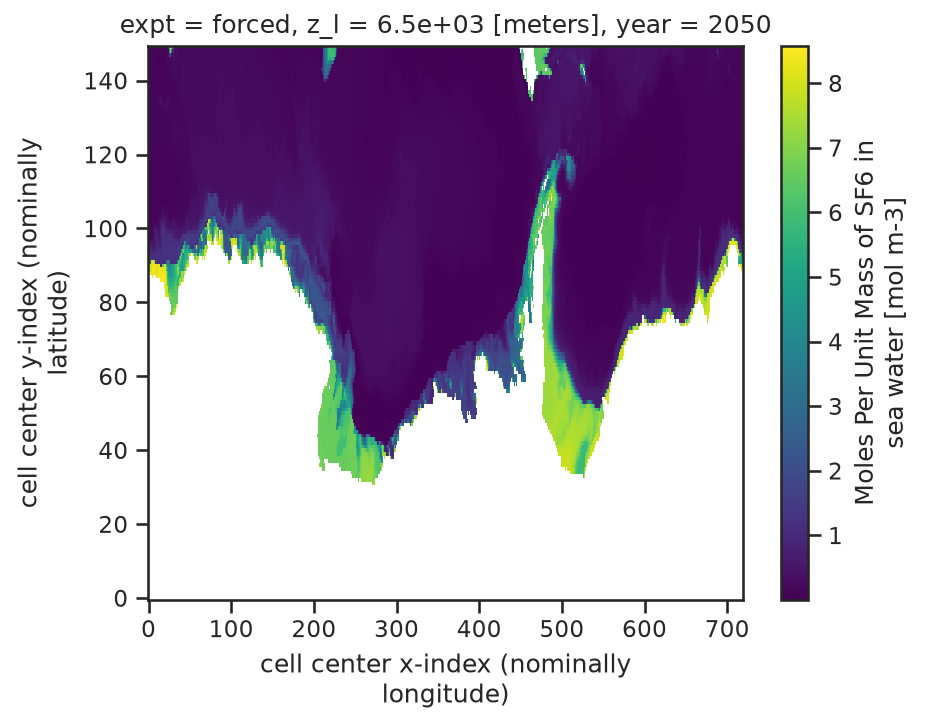

In [16]:
bottom_sf6 = ds["sf6"].ffill("z_l").isel(z_l = -1).compute()
bottom_sf6 = bottom_sf6 * 1e12 / 1035 * 1e3
bottom_sf6 = bottom_sf6.where(bottom_sf6.deptho > 100)
bottom_sf6.isel(expt = 1).sel(year = 2050).plot()

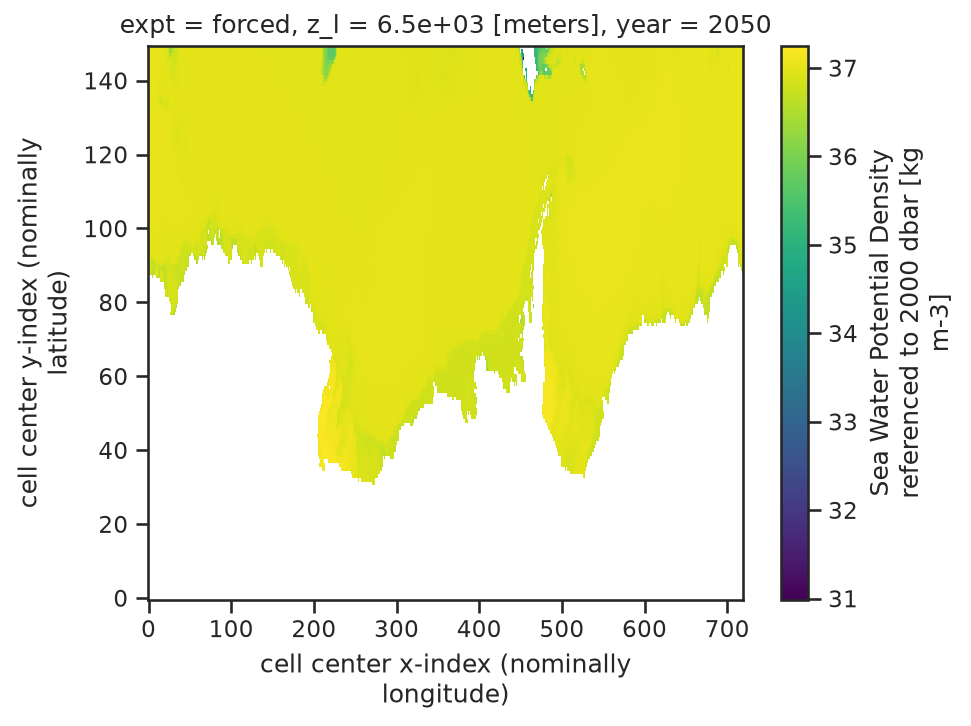

In [17]:
bottom_sigma2_offline = ds["sigma2_offline"].ffill("z_l").isel(z_l = -1).compute()
bottom_sigma2_offline = bottom_sigma2_offline.where(bottom_sigma2_offline.deptho > 100)

bottom_sigma2_offline.isel(expt = 1).sel(year = 2050).plot()

In [18]:
time_mean_transects = avg_transects.sel(year = slice(-10, None)).mean("year", skipna = True).compute() 

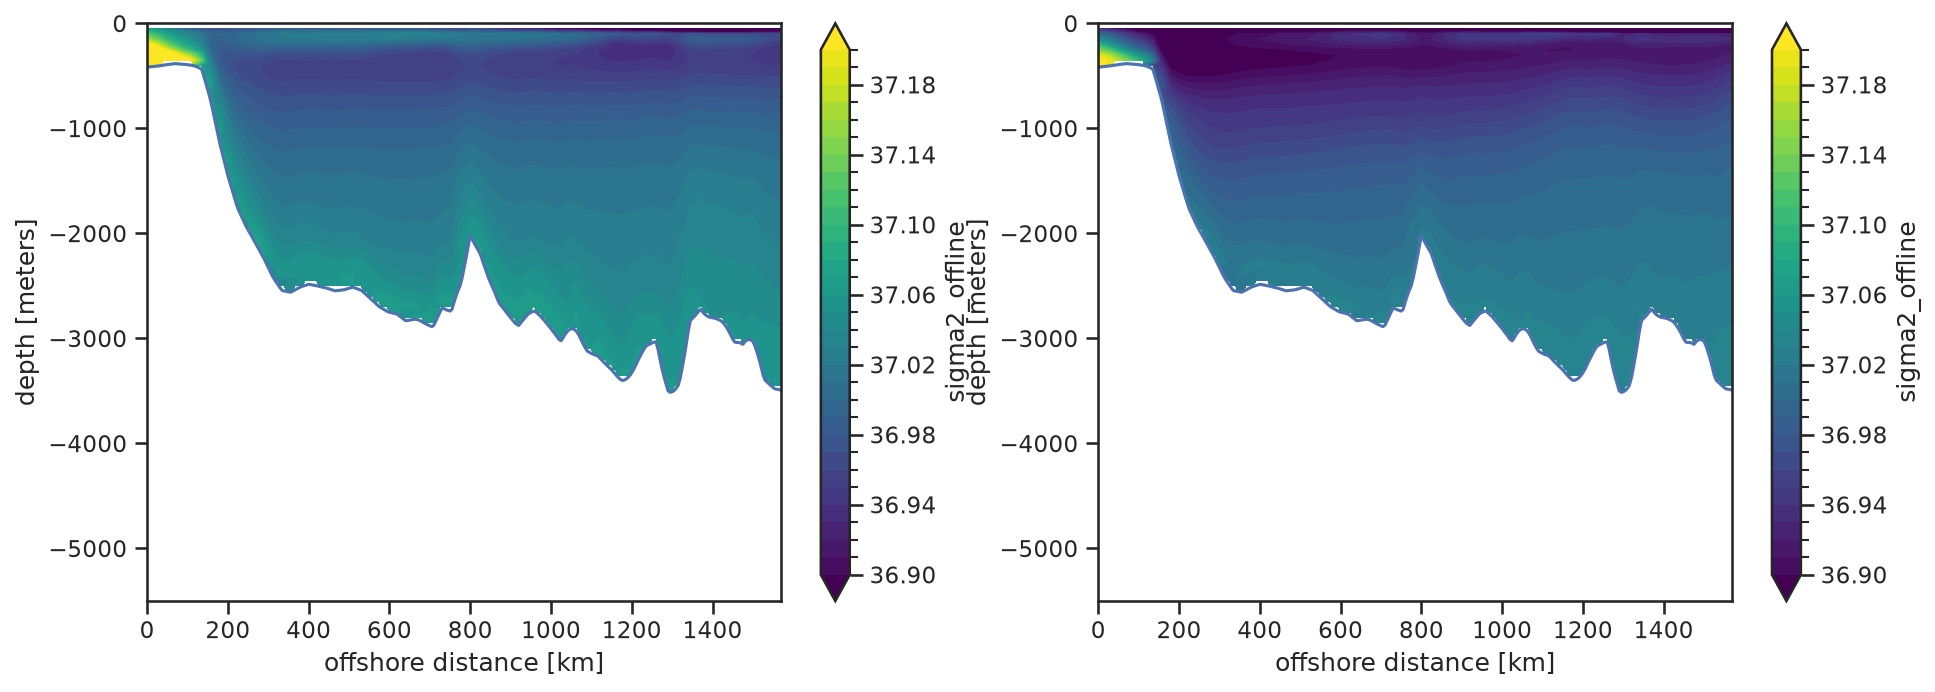

In [19]:
fig, ax = plt.subplots(1,2, figsize = (15, 5))
levels =  np.arange(36.9, 37.2 + 1e-16, 0.01)

time_mean_var = time_mean_transects.sigma2_offline
time_mean_var.sel(expt = "control").plot.contourf(ax = ax[0], yincrease = True, levels= levels)
time_mean_var.sel(expt = "forced").plot.contourf(ax = ax[1],yincrease = True, levels= levels)

for a in ax: 
    (-time_mean_transects.deptho).plot(ax = a,yincrease = True)
    a.set_ylabel("depth [meters]")
    a.set_xlabel("offshore distance [km]")
    a.scatter(
        s_tie,
        np.full(len(s_tie), 1.03),
        marker="",
        s=70,
        color="k",
        transform=a.get_xaxis_transform(),
        clip_on=False,
        zorder=20,
    )
    

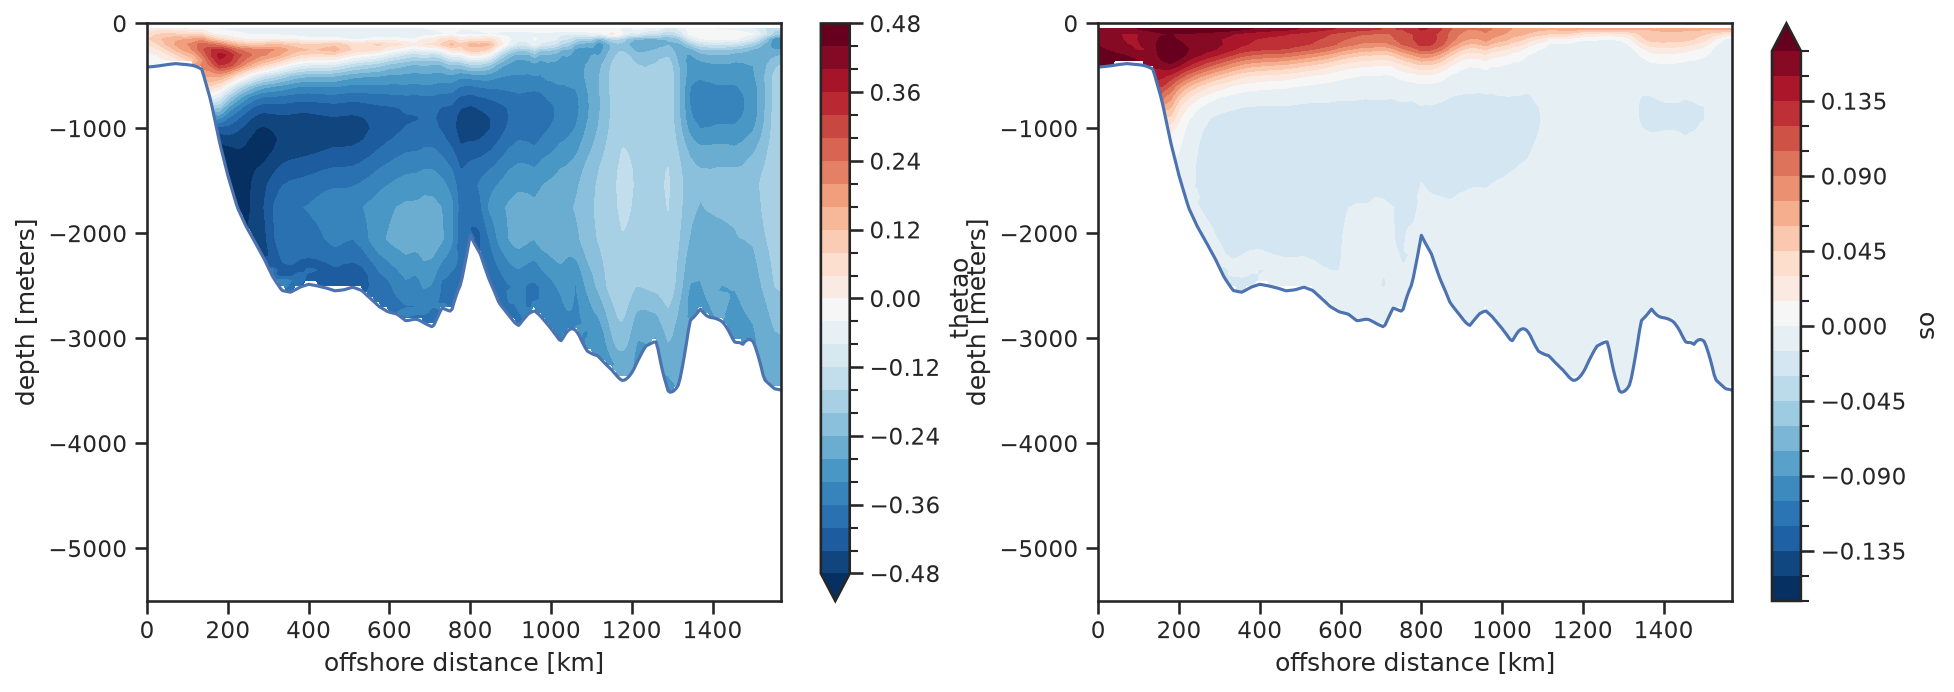

In [20]:
fig, ax = plt.subplots(1,2, figsize = (15, 5))
levels =  np.arange(36.9, 37.2 + 1e-16, 0.01)

time_mean_var = time_mean_transects.thetao
(time_mean_var.sel(expt = "control") - time_mean_var.sel(expt = "forced")).plot.contourf(ax = ax[0], yincrease = True, levels= 25, robust = True)
time_mean_var = time_mean_transects.so
(time_mean_var.sel(expt = "control") - time_mean_var.sel(expt = "forced")).plot.contourf(ax = ax[1], yincrease = True, levels= 25, robust = True)

for a in ax: 
    (-time_mean_transects.deptho).plot(ax = a,yincrease = True)
    a.set_ylabel("depth [meters]")
    a.set_xlabel("offshore distance [km]")
    a.scatter(
        s_tie,
        np.full(len(s_tie), 1.03),
        marker="",
        s=70,
        color="k",
        transform=a.get_xaxis_transform(),
        clip_on=False,
        zorder=20,
    )
    

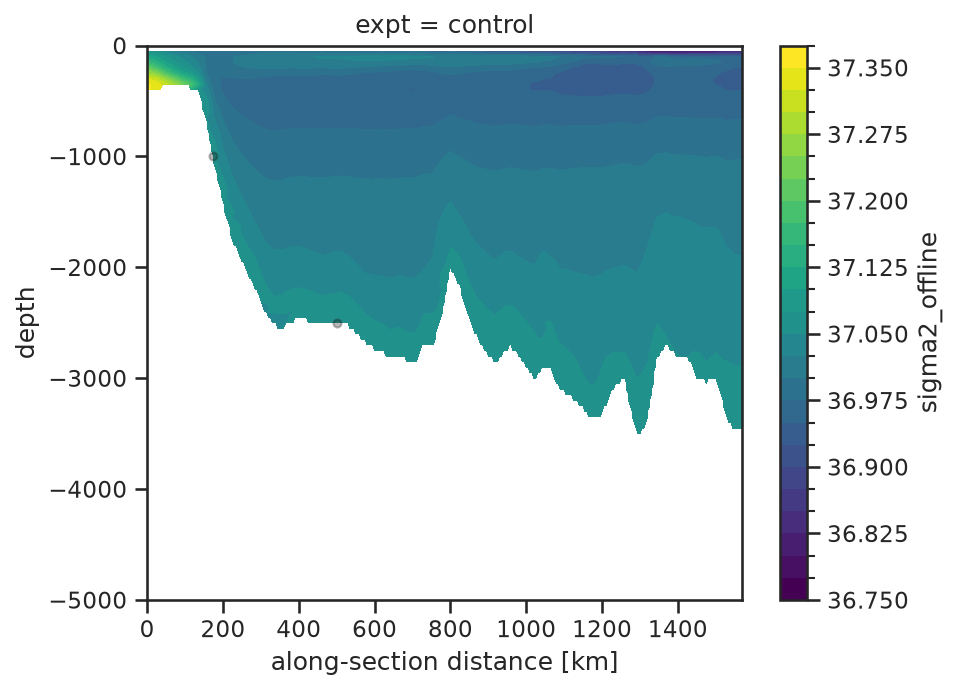

In [21]:
surf_loc = (175, -1000)
bot_loc = (500, -2500)


lat_s, z_s = surf_loc
lat_b, z_b = bot_loc

avg_trans = avg_transects.interp(
    year=np.arange(1850, 2100),
    method="nearest",
    kwargs={"fill_value": np.nan},
)

last = avg_trans.sel(year=2099).assign_coords(year=2100)
avg_trans = xr.concat([avg_trans, last], dim="year")

avg_trans = avg_trans.sel(depth = slice(-5000, None))

fig, ax = plt.subplots()
avg_trans.sigma2_offline.where(avg_trans.sigma2_offline > 0.0).mean("year").sel(expt = "control").plot.contourf(ax = ax, zorder = 0, levels = 25)

ax.scatter(lat_s, z_s, c = "k", s = 15, zorder = 100, alpha = 0.3)
ax.scatter(lat_b, z_b, c = "k", s = 15, zorder = 100, alpha = 0.3)


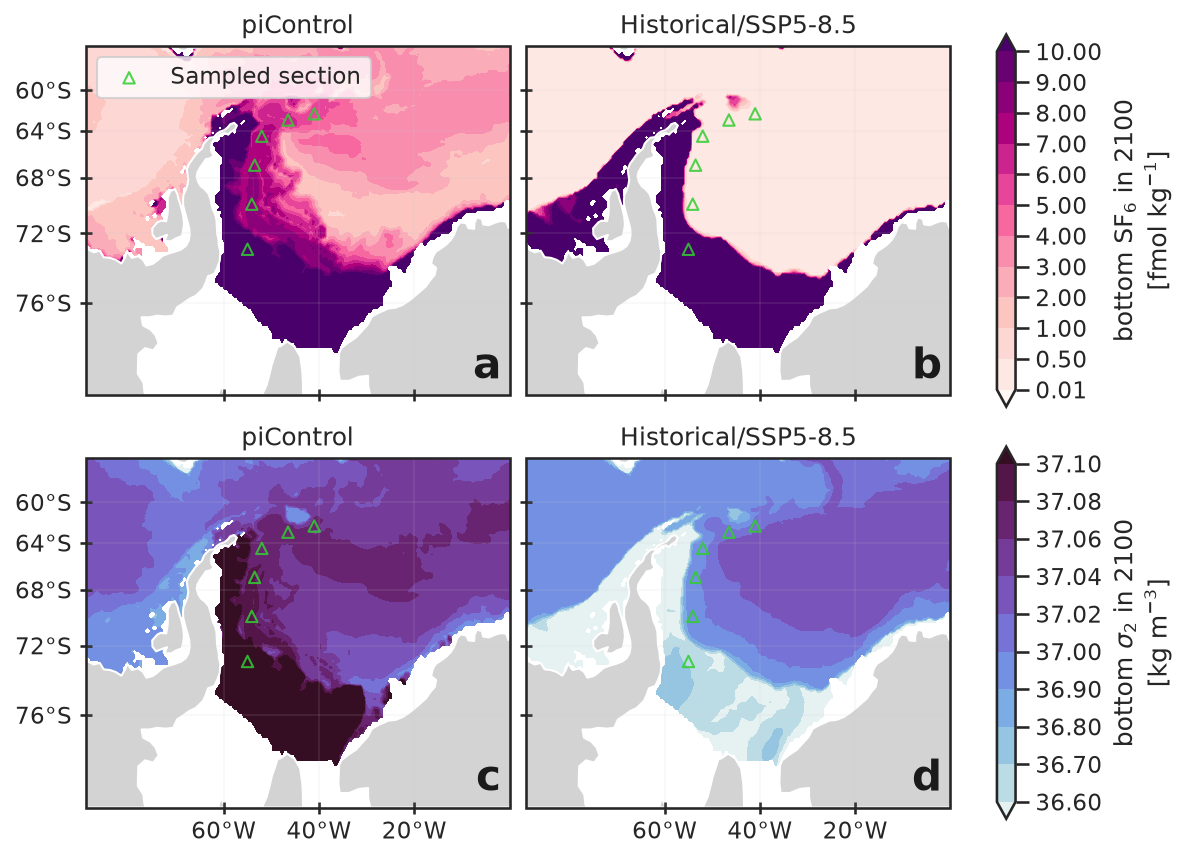

In [22]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import cmocean.cm as cmo
from matplotlib.colors import BoundaryNorm
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

year = 2100
map_extent = (-89, 0, -80, -55)

expts = ["control", "forced"]
expt_labels = {
    "control": "piControl",
    "forced": "Historical/SSP5-8.5",
}
panel_labels = np.array([
    ["A", "B"],
    ["C", "D"],
])

data_crs = ccrs.PlateCarree()
map_crs = ccrs.Mercator(
    min_latitude=map_extent[2],
    max_latitude=map_extent[3],
    latitude_true_scale=-70,
)

land = cfeature.NaturalEarthFeature(
    "physical",
    "land",
    "110m",
    facecolor="lightgrey",
)

sf6_bounds = np.r_[0.01, 0.5, np.arange(1.0, 11.0, 1.0)]
cmap_sf6 = plt.get_cmap("RdPu", len(sf6_bounds) + 1)
norm_sf6 = BoundaryNorm(sf6_bounds, ncolors=cmap_sf6.N, extend="both")

sigma2_bounds = np.r_[
    [36.6, 36.7, 36.8, 36.9],
    np.arange(37.0, 37.1, 0.02),
]
cmap_sigma = plt.get_cmap(cmo.dense, len(sigma2_bounds) + 1)
norm_sigma = BoundaryNorm(sigma2_bounds, ncolors=cmap_sigma.N, extend="both")


plot_specs = [
    {
        "data": bottom_sf6.sel(year=year, method = "nearest"),
        "bounds": sf6_bounds,
        "cmap": cmap_sf6,
        "cbar_label": rf"bottom SF$_6$ in {year}" + "\n" + r"[fmol kg$^{-1}$]",
        "norm":norm_sf6, 
    },
    {
        "data": bottom_sigma2_offline.sel(year=year, method = "nearest"),
        "bounds": sigma2_bounds,
        "cmap": cmap_sigma,
        "cbar_label": rf"bottom $\sigma_2$ in {year}" + "\n" + r"[kg m$^{-3}$]",
        "norm":norm_sigma, 
    },
]

fig = plt.figure(figsize=(8, 7))
gs = fig.add_gridspec(
    nrows=2,
    ncols=2,
    wspace=0.04,
    hspace=0.04,
)

axes = np.array([
    [fig.add_subplot(gs[row, col], projection=map_crs) for col in range(2)]
    for row in range(2)
])

for row, spec in enumerate(plot_specs):
    bounds = spec["bounds"]
    cmap = spec["cmap"]
    norm =  spec["norm"]

    for col, expt in enumerate(expts):
        ax = axes[row, col]
        da = spec["data"].sel(expt=expt)

        # mesh = ax.pcolormesh(
        #     da.lon,
        #     da.lat,
        #     da,
        #     transform=data_crs,
        #     cmap=cmap,
        #     norm=norm,
        #     zorder=0,
        # )
        mesh = ax.contourf(
            da.lon,
            da.lat,
            da,
            levels=bounds,
            transform=data_crs,
            cmap=cmap,
            norm=norm,
            extend="both",
            zorder=0,
        )

        ax.set_extent(map_extent, crs=data_crs)
        # ax.coastlines(resolution="110m", linewidth=0.5, zorder=3)
        ax.add_feature(land, zorder=0)

        ax.scatter(
            lon_tie,
            lat_tie,
            transform=data_crs,
            s=30,
            edgecolor="limegreen",
            marker = "^", 
            facecolor = "None",
            alpha=0.85,
            zorder=10,
            label="Sampled section" if (row, col) == (0, 0) else None,
        )

        ax.set_title(expt_labels[expt])

        ax.text(
            0.98,
            0.02,
            panel_labels[row, col].lower(),
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=20,
            fontweight="bold",
            color="k",
            zorder=30,
        )

        if (row, col) == (0, 0):
            ax.legend(loc="upper left", frameon=True)
        
        xticks = np.arange(-60, -19, 20)
        yticks = np.arange(-76, -59, 4)
        gl = ax.gridlines(draw_labels=False, crs=data_crs, alpha=0.1)
        gl.xlocator = mticker.FixedLocator(xticks)
        gl.ylocator = mticker.FixedLocator(yticks)
        
        ax.set_xticks(xticks, crs=data_crs)
        ax.set_yticks(yticks, crs=data_crs)
        ax.xaxis.set_major_formatter(LongitudeFormatter(dateline_direction_label=True))
        ax.yaxis.set_major_formatter(LatitudeFormatter())

        ax.tick_params(direction = "inout", labelleft= (col == 0) , labelbottom= (row == 1), zorder = 100)
                            
    
    cbar = fig.colorbar(
        mesh,
        ax=axes[row, :],
        orientation="vertical",
        ticks=bounds,
        fraction = 0.02, 
        spacing="uniform",
        extend="both",
    )
    cbar.set_label(spec["cbar_label"])

fig.savefig(
    "plots/6.Weddell_density_and_sf6_maps.png",
    dpi=350,
    bbox_inches="tight",
)

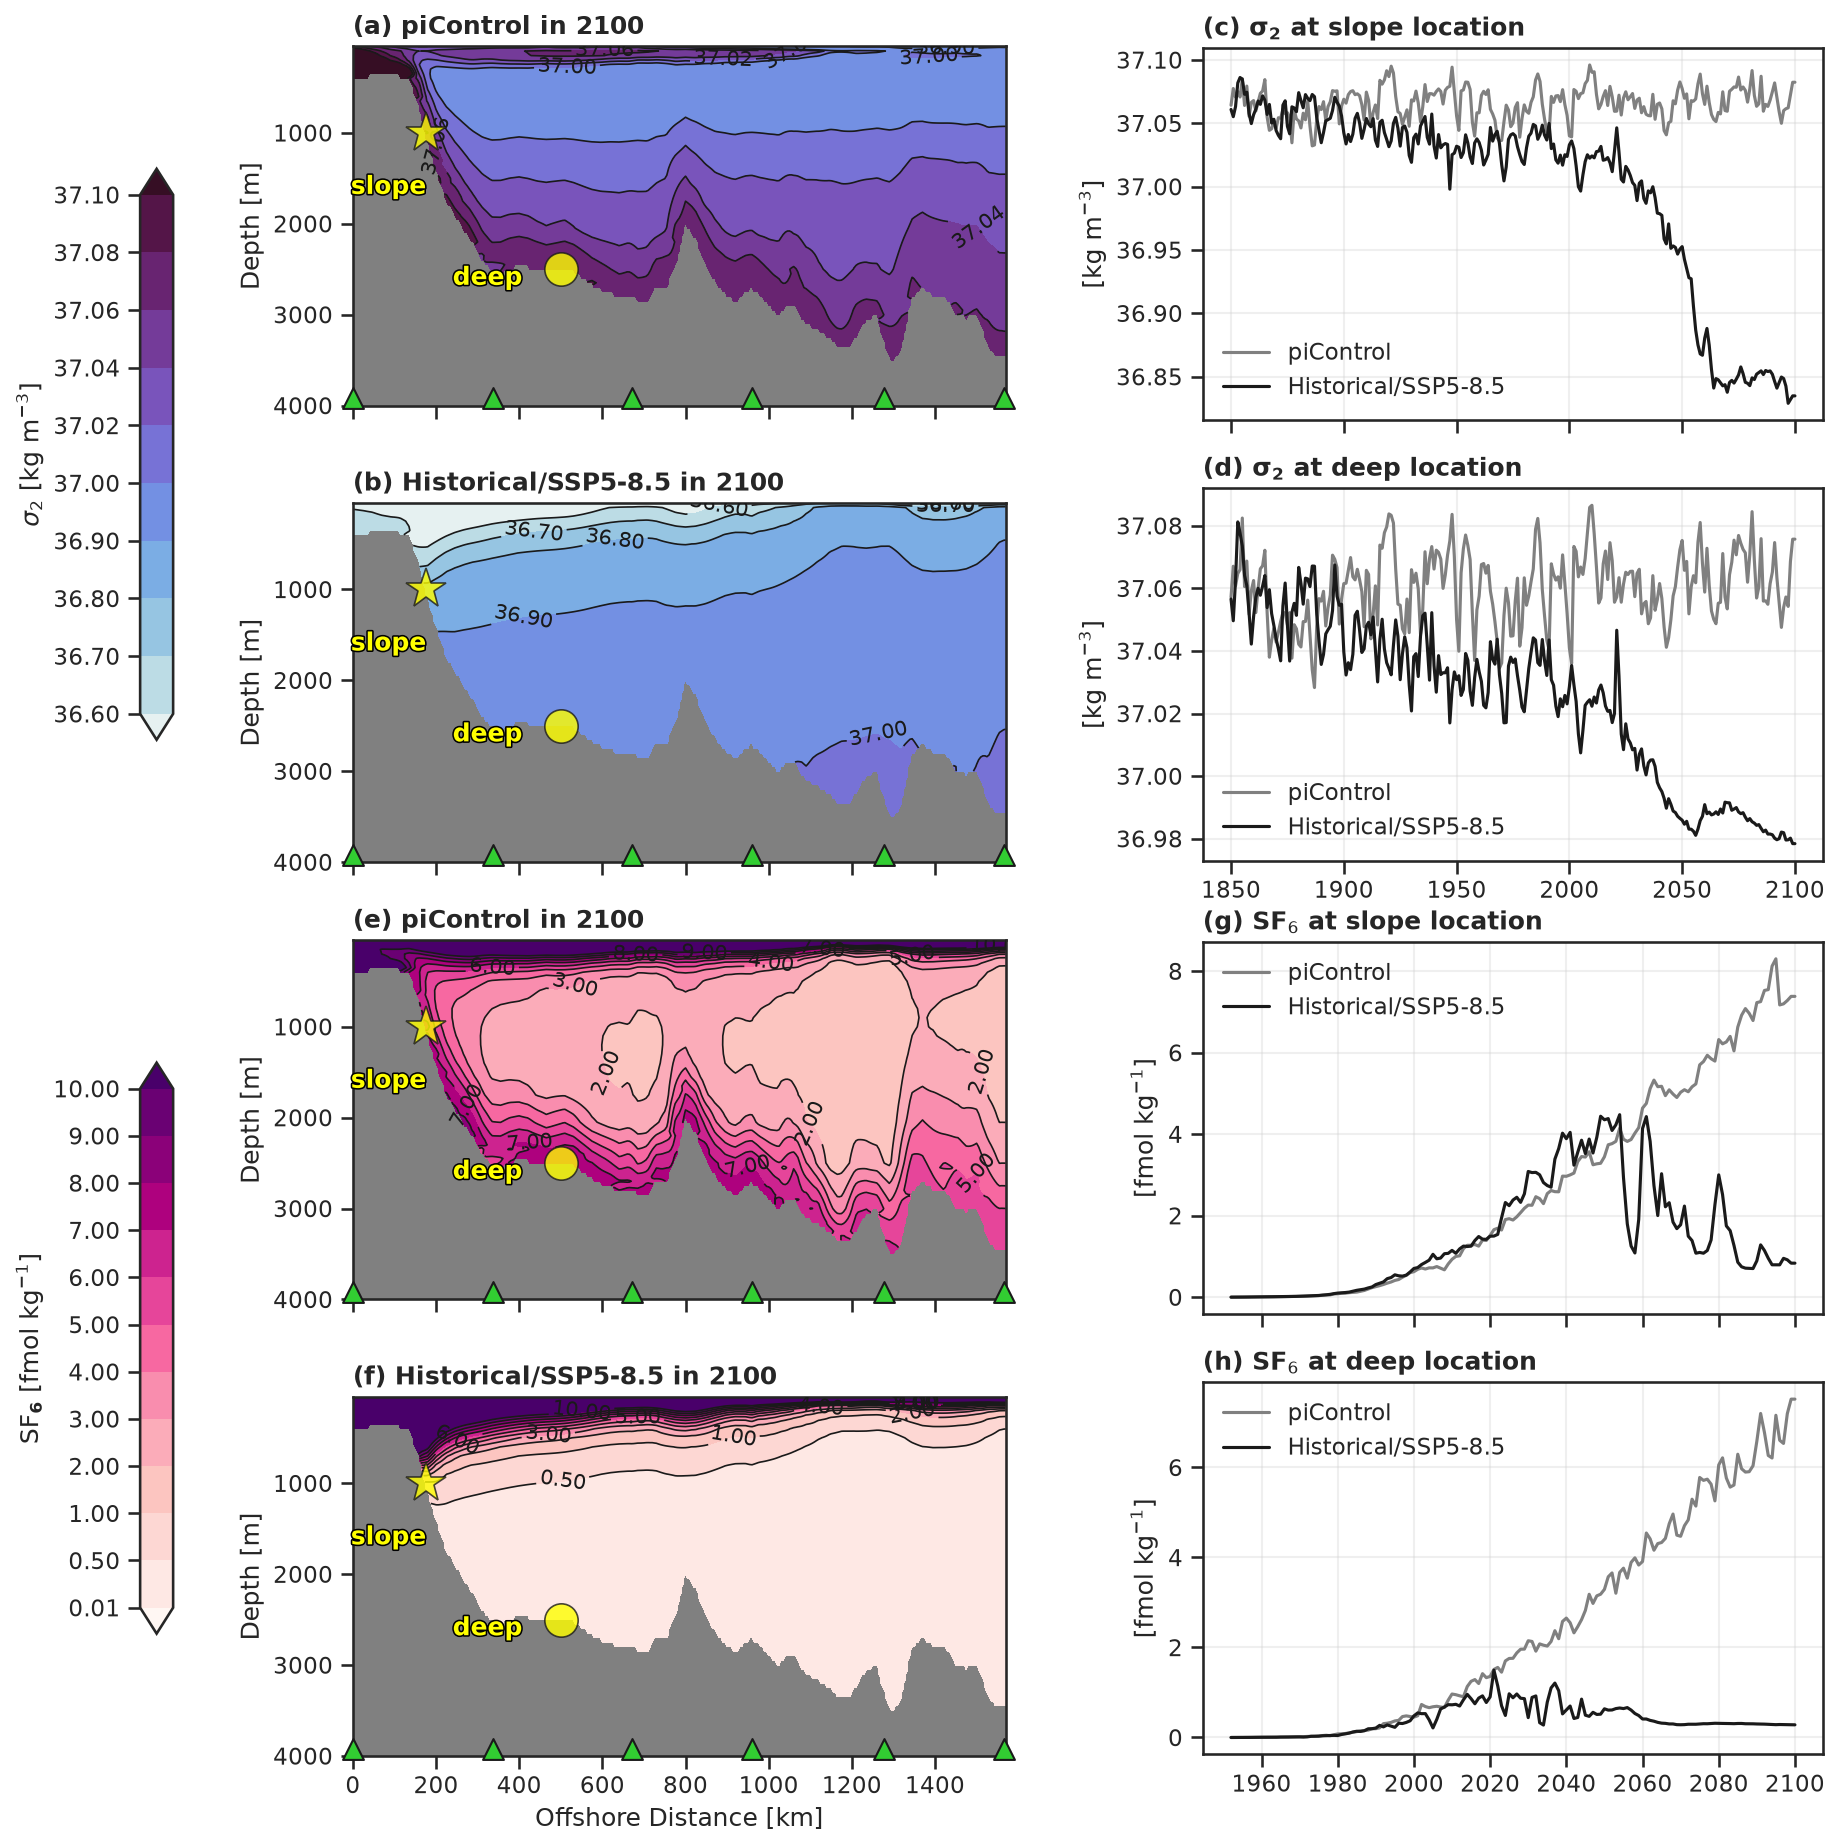

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable
import matplotlib.transforms as mtransforms


def plot_row(
    fig,
    axs,
    var,
    levels,
    cmap,
    year,
    units,
    cbar_label,
    section_titles,
    timeseries_titles,
    z=slice(None),
    scale=1.0,
    contour_fmt="%g",
    surf_loc=(380, -430),
    bot_loc=(680, -3000),
    plot_contours=True,
    clabel_colors="k",
    clabel_fontsize=10,
    add_time_label=True,
    add_units=False,
    hide_section_xlabel=False,
    cbar_width=0.014,
    cbar_pad=0.06,
):
    required_axes = {"section_control", "section_forced", "surf", "bot"}
    missing_axes = required_axes - set(axs)
    if missing_axes:
        raise KeyError(f"axs is missing axes: {sorted(missing_axes)}")

    if len(section_titles) != 2:
        raise ValueError("section_titles must have length 2.")

    if len(timeseries_titles) != 2:
        raise ValueError("timeseries_titles must have length 2.")

    section_specs = [
        (axs["section_control"], "control", section_titles[0]),
        (axs["section_forced"], "forced", section_titles[1]),
    ]

    site_specs = {
        "surf": {
            "axis": axs["surf"],
            "loc": surf_loc,
            "label": "slope",
            "title": timeseries_titles[0],
            "marker": "*",
            "ms": 20,
            "text_dx": -180,
            "text_dz": 600,
        },
        "bot": {
            "axis": axs["bot"],
            "loc": bot_loc,
            "label": "deep",
            "title": timeseries_titles[1],
            "marker": "o",
            "ms": 16,
            "text_dx": -260,
            "text_dz": 100,
        },
    }

    expt_colors = {
        "control": "grey",
        "forced": "k",
    }

    expt_labels = {
        "control": "piControl",
        "forced": "Historical/SSP5-8.5",
    }

    var = var.sel(depth=z) * scale
    v = var.sel(year=year)

    cmap = cmap.copy()

    n_regions = len(levels) - 1 + 2
    if cmap.N < n_regions:
        cmap = cmap.resampled(n_regions)

    explicit_norm = BoundaryNorm(levels, ncolors=cmap.N, extend="both")

    for ax, expt, title in section_specs:
        da = v.sel(expt=expt).transpose("depth", "transect_length")

        pm = ax.contourf(
            da.transect_length,
            np.abs(da.depth),
            da,
            cmap=cmap,
            norm=explicit_norm,
            levels = levels, 
            extend = "both", 
            # shading="auto",
        )

        trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)

        ax.scatter(
            s_tie,
            0.02 + np.zeros_like(s_tie),
            edgecolor="k",
            c = "limegreen",
            marker="^",
            # facecolor="None",
            transform=trans,
            clip_on=False,
            s = 100, 
            zorder=20,
        )

        if plot_contours:
            cs = ax.contour(
                da.transect_length,
                np.abs(da.depth),
                da,
                levels=levels,
                colors=clabel_colors,
                linewidths=0.8,
            )

            ax.clabel(
                cs,
                cs.levels,
                inline=True,
                fontsize=clabel_fontsize,
                fmt=contour_fmt,
            )

        for site in site_specs.values():
            x, z0 = site["loc"]

            ax.plot(
                x,
                np.abs(z0),
                marker=site["marker"],
                ms=site["ms"],
                mfc="yellow",
                mec="k",
                mew=0.8,
                zorder=10,
                alpha=0.8,
            )

            ax.text(
                x + site["text_dx"],
                np.abs(z0 - site["text_dz"]),
                site["label"],
                ha="left",
                va="center",
                color="yellow",
                fontweight="bold",
                zorder=11,
                path_effects=[
                    pe.Stroke(linewidth=1.5, foreground="black"),
                    pe.Normal(),
                ],
            )

        ax.invert_yaxis()
        ax.set_facecolor("grey")
        ax.set_ylabel("Depth [m]")
        ax.set_title(title, loc="left", fontweight="bold")

    if hide_section_xlabel:
        axs["section_control"].set_xlabel("")
        axs["section_forced"].set_xlabel("")
        axs["section_control"].tick_params(labelbottom=False)
        axs["section_forced"].tick_params(labelbottom=False)
    else:
        axs["section_control"].set_xlabel("")
        axs["section_forced"].set_xlabel("Offshore Distance [km]")
        axs["section_control"].tick_params(labelbottom=False)

    section_gap = 0.05

    pos0 = axs["section_control"].get_position()
    pos1 = axs["section_forced"].get_position()

    bottom = pos1.y0
    top = pos0.y1
    height = (top - bottom - section_gap) / 2

    axs["section_forced"].set_position([
        pos1.x0,
        bottom,
        pos1.width,
        height,
    ])

    axs["section_control"].set_position([
        pos0.x0,
        bottom + height + section_gap,
        pos0.width,
        height,
    ])

    cbar_height_frac = 0.7
    cbar_height = (top - bottom) * cbar_height_frac
    cbar_bottom = bottom + 0.5 * ((top - bottom) - cbar_height)
    
    cax = fig.add_axes([
        pos0.x0 - cbar_pad - cbar_width,
        cbar_bottom,
        cbar_width,
        cbar_height,
    ])

    mappable = ScalarMappable(norm=explicit_norm, cmap=cmap)

    cbar = fig.colorbar(
        mappable,
        cax=cax,
        orientation="vertical",
        ticks=levels,
        spacing="uniform",
        extend="both",
    )

    cbar.set_ticklabels([contour_fmt % val for val in levels])
    cbar.set_label(cbar_label)
    cbar.ax.yaxis.set_ticks_position("left")
    cbar.ax.yaxis.set_label_position("left")

    site_ts = {}

    for name, site in site_specs.items():
        x, z0 = site["loc"]

        site_ts[name] = var.interp(
            transect_length=x,
            depth=z0,
            method="nearest",
            kwargs={"fill_value": np.nan},
        )

        ax = site["axis"]

        for expt, color in expt_colors.items():
            ax.plot(
                site_ts[name].year,
                site_ts[name].sel(expt=expt),
                c=color,
                label=expt_labels[expt],
            )

        ax.set_title(site["title"], loc="left", fontweight="bold")
        ax.set_ylabel(f"[{units}]")
        ax.grid(alpha=0.3)
        ax.legend(frameon=False)

    axs["surf"].tick_params(labelbottom=False)

    return {
        **axs,
        "pm": pm,
        "cax": cax,
        "cbar": cbar,
        "site_ts": site_ts,
        "ts": site_ts["surf"],
        "tb": site_ts["bot"],
    }


z_slice = slice(-4000, -10)

fig = plt.figure(figsize=(11, 13), constrained_layout=False)

gs = fig.add_gridspec(
    2,
    2,
    width_ratios=(1.1, 1.0),
    height_ratios=(1.0, 1.0),
    wspace=0.28,
    hspace=0.015,
)

fig.subplots_adjust(
    left=0.08,
    right=0.98,
    bottom=0.06,
    top=0.97,
)

axs = {}

for row in range(2):
    gs_section = gs[row, 0].subgridspec(2, 1, hspace=0.0)
    gs_timeseries = gs[row, 1].subgridspec(2, 1, hspace=0.0)

    axs[row] = {}

    axs[row]["section_control"] = fig.add_subplot(gs_section[0, 0])
    axs[row]["section_forced"] = fig.add_subplot(
        gs_section[1, 0],
        sharex=axs[row]["section_control"],
    )

    axs[row]["surf"] = fig.add_subplot(gs_timeseries[0, 0])
    axs[row]["bot"] = fig.add_subplot(
        gs_timeseries[1, 0],
        sharex=axs[row]["surf"],
    )

for row in range(2):
    for key in ["section_control", "section_forced"]:
        axs[row][key].set_box_aspect(0.55)

    for key in ["surf", "bot"]:
        axs[row][key].set_box_aspect(0.6)


max_gap = 0

axs1 = plot_row(
    fig=fig,
    axs=axs[0],
    var=avg_trans.sigma2_offline.interpolate_na(
        dim="transect_length",
        max_gap=max_gap,
    ),
    levels=sigma2_bounds,
    cmap=cmap_sigma,
    year=year,
    units=r"kg m$^{-3}$",
    cbar_label=r"${\sigma_2}$ [kg m$^{-3}$]",
    section_titles=[
        rf"(a) piControl in {year}",
        rf"(b) Historical/SSP5-8.5 in {year}",
    ],
    timeseries_titles=[
        r"(c) $\mathbf{\sigma_2}$ at slope location",
        r"(d) $\mathbf{\sigma_2}$ at deep location",
    ],
    z=z_slice,
    contour_fmt="%.2f",
    surf_loc=surf_loc,
    bot_loc=bot_loc,
    hide_section_xlabel=True,
    cbar_width=0.02,
    cbar_pad=0.1,
)

axs2 = plot_row(
    fig=fig,
    axs=axs[1],
    var=avg_trans.sf6.interpolate_na(
        dim="transect_length",
        max_gap=max_gap,
    ),
    levels=sf6_bounds,
    cmap=cmap_sf6,
    year=year,
    units=r"fmol kg$^{-1}$",
    cbar_label=r"SF$\mathbf{_6}$ [fmol kg$^{-1}$]",
    section_titles=[
        rf"(e) piControl in {year}",
        rf"(f) Historical/SSP5-8.5 in {year}",
    ],
    timeseries_titles=[
        r"(g) SF$\mathrm{_6}$ at slope location",
        r"(h) SF$\mathrm{_6}$ at deep location",
    ],
    z=z_slice,
    scale=1e12 / 1035 * 1e3,
    contour_fmt="%.2f",
    surf_loc=surf_loc,
    bot_loc=bot_loc,
    hide_section_xlabel=False,
    cbar_width=0.02,
    cbar_pad=0.1,
)

fig.savefig(
    "plots/6.Weddell_density_and_sf6.png",
    dpi=350,
    bbox_inches="tight",
)

In [24]:
def calc_p_from_z(z, lat):
    """Calculates pressure from depth z (must be negative downwards) and latitude."""
    return xr.apply_ufunc(
        gsw.p_from_z,
        z, lat,
        dask='parallelized',
        output_dtypes=[float]
    )
def calc_sigma2(SA, CT):
    """Calculates sigma2 using apply_ufunc for safe Dask/Xarray handling."""
    return xr.apply_ufunc(
        gsw.sigma2,
        SA, CT,
        dask='parallelized',
        output_dtypes=[float]
    )

def calc_rho_alpha_beta(SA, CT, p):
    """
    Calculates rho, alpha, and beta using apply_ufunc.
    gsw.rho_alpha_beta returns 3 variables, requiring output_core_dims.
    """
    return xr.apply_ufunc(
        gsw.rho_alpha_beta,
        SA, CT, p,
        dask='parallelized',
        output_core_dims=[[], [], []],
        output_dtypes=[float, float, float]
    )
    

In [25]:
avg_transects_copy = 1.0 * avg_trans

avg_transects_copy['sigma2_obs'] = calc_sigma2(
    avg_transects_copy.so.astype("float64"),
    avg_transects_copy.thetao.astype("float64"))

window = 2100
# select locations
ts = avg_transects_copy.interp(transect_length=lat_s, depth=z_s, method="nearest",
    kwargs={"fill_value": np.nan},).sel(year = slice(None, window))
tb = avg_transects_copy.interp(transect_length=lat_b, depth=z_b, method="nearest",
    kwargs={"fill_value": np.nan},).sel(year = slice(None, window))

time = ts.year
# Point 1 (Upper)
SA_1 = ts["so"].astype("float64")
CT_1 = ts["thetao"]
PT_1 = ts['sigma2_offline']
# Point 2 (Lower)
SA_2 = tb["so"]
CT_2 =  tb["thetao"]
PT_2 = tb['sigma2_offline']

# Actual Sigma-2 Difference
#sigma2_obs is biased high compared to sigma2_offline (i.e., sigma2_obs is lighter than sigma2_offline
#but the differences (PT_2 - PT_1) are approximately the same.
density_difference_ds = (-(PT_2 - PT_1)).to_dataset(name = "actual_sigma2_diff") 

# Linear Reconstruction Components
delta_CT =  -(CT_2 - CT_1)
delta_SA = -(SA_2 - SA_1)

mid_CT = (CT_2 + CT_1) / 2
mid_SA = (SA_2 + SA_1) / 2
p_ref = 2000.0 # sigma2 reference pressure

rho_mid, alpha_mid, beta_mid = calc_rho_alpha_beta(mid_SA, mid_CT, p_ref)

density_difference_ds["T_contribution"] = (-rho_mid * alpha_mid * delta_CT)
density_difference_ds["S_contribution"] = rho_mid * beta_mid * delta_SA
density_difference_ds["reconstructed_sigma2_diff"] = density_difference_ds["T_contribution"] + density_difference_ds["S_contribution"]

In [26]:
toTg = 1e-9 
mass_flux_units = r"Tg s^{-1}"
mass_flux_units_conversion = toTg #kg to Tg 

ds_sfc = xr.open_mfdataset(outputdir(f"Southern_Ocean_DSW_1000m_WMT_Surface_Fluxes_sigma_slice.zarr"))
ds_sfc_SWMT = get_SWMT(ds_sfc)
Wedell_DSW_SWMT = ds_sfc_SWMT.isel(xh = slice(157, 190)).sum(["xh", "yh"])
Wedell_DSW_SWMT["SWMT_residual"] = Wedell_DSW_SWMT["SWMT_salt_residual"] + Wedell_DSW_SWMT["SWMT_heat_residual"] 

In [27]:
?select_from_location

Signature: select_from_location(ds, ds_loc, dim='sigma2_l_target')
Docstring: Select data from maximum locations in control and forced experiments.
File:      ~/CM4XAbyssalSWMT/src/select_max_loc.py
Type:      function

In [28]:
abyssal_sbf = Wedell_DSW_SWMT["SWMT"].fillna(0.0)

max_locations = abyssal_sbf.argmax("sigma2_l").compute()

control_max = abyssal_sbf["sigma2_l"][max_locations.sel(exp = "control")].rename("max_surface_boundary_flux_density")
forced_max = abyssal_sbf["sigma2_l"][max_locations.sel(exp = "forced")].rename("max_surface_boundary_flux_density")

max_sbf_weddell_loc = xr.concat([control_max, forced_max], dim = "exp").compute()
max_sbf_weddell = toTg * select_from_location(Wedell_DSW_SWMT, max_sbf_weddell_loc, dim = "sigma2_l").compute()

/user/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/distributed/client.py:3415: UserWarning: Sending large graph of size 11.19 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [29]:
dim = "sigma2_l"

sbf = Wedell_DSW_SWMT["SWMT"].compute()
mask = sbf.notnull() & (sbf > 1e-6)

idx = xr.DataArray(
    np.arange(sbf.sizes[dim]),
    dims=dim,
    coords={dim: sbf[dim]},
)

last_arg = idx.where(mask, other=-1).max(dim).astype("int64")
last_loc = sbf[dim].isel({dim: last_arg}).where(last_arg >= 0).rename(
    "last_positive_surface_boundary_flux_density"
)

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FormatStrFormatter

def piecewise_ticks(edges, steps):
    ticks = []
    for i, step in enumerate(steps):
        start, stop = edges[i], edges[i + 1]
        t = np.arange(start, stop + 1e-12, step)
        if i > 0:
            t = t[1:]  # drop repeated breakpoint
        ticks.append(t)
    return np.concatenate(ticks)


def set_uniform_tickscale_y(ax, yticks, *, fmt="%.2f"):
    yticks = np.asarray(yticks, dtype=float)
    ypos = np.arange(yticks.size, dtype=float)

    if np.any(np.diff(yticks) <= 0):
        raise ValueError("yticks must be strictly increasing.")

    def forward(y):
        return np.interp(y, yticks, ypos)

    def inverse(yp):
        return np.interp(yp, ypos, yticks)

    ax.set_yscale("function", functions=(forward, inverse))
    ax.yaxis.set_major_locator(FixedLocator(yticks))
    ax.yaxis.set_major_formatter(FormatStrFormatter(fmt))
    ax.set_ylim(yticks[0], yticks[-1])

    return ax

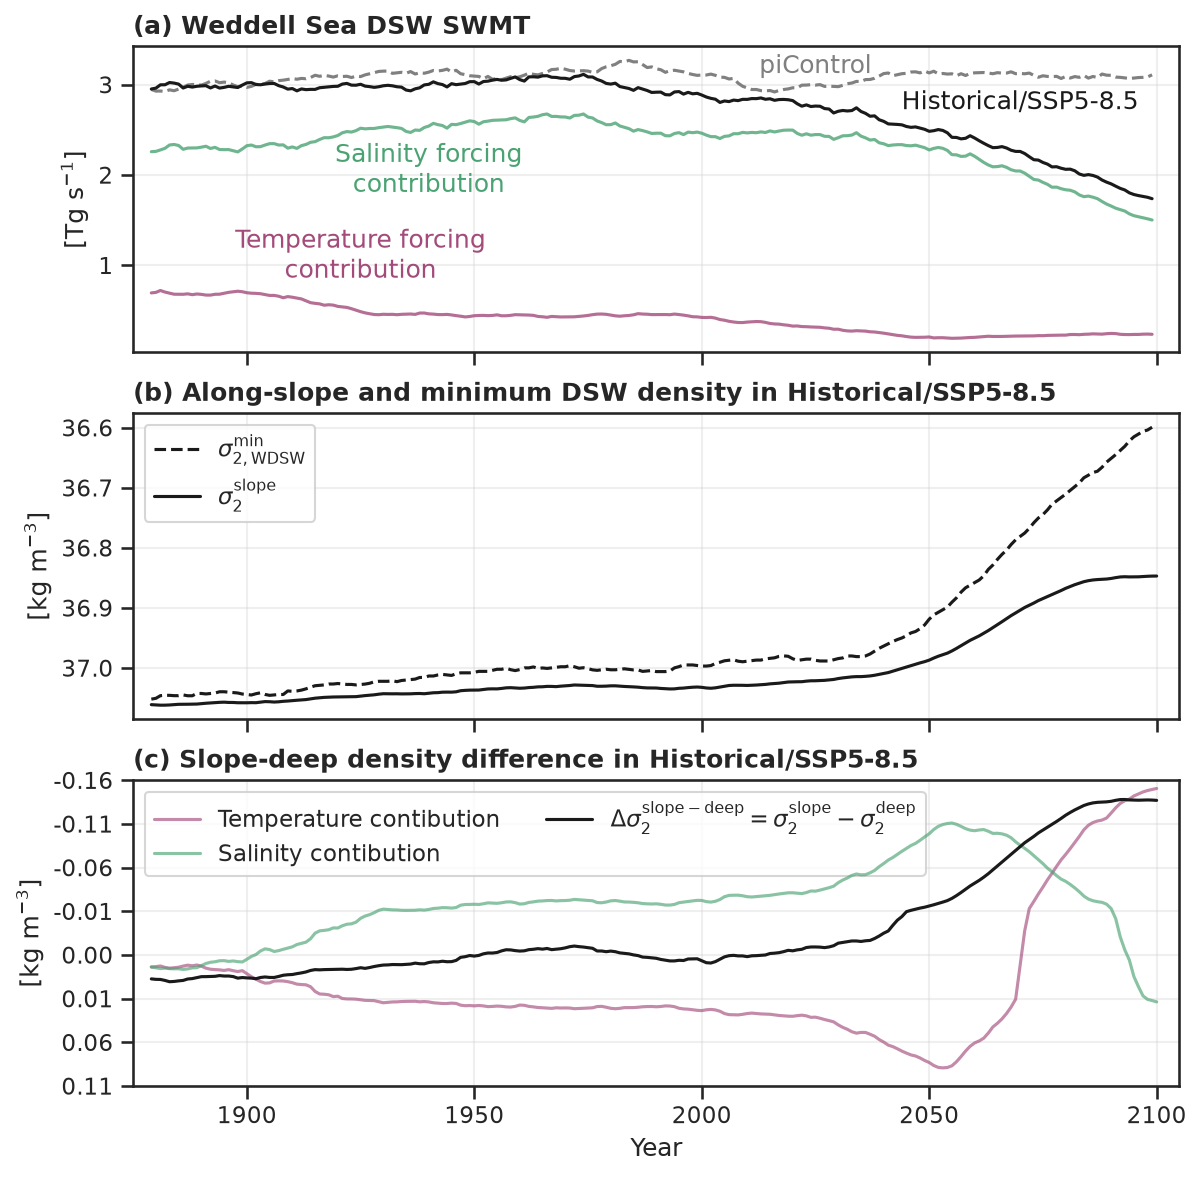

In [31]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

rolling_window = 30
center = False

roll = lambda x: x.rolling(year=rolling_window, center=center).mean("year")

swmt_colors = {"temperature": "#A34B7B", "salinity": "#4BA373"}
expt_colors = {"forced": "k", "control": "grey"}
expt_labels = {"forced": r"Historical/SSP5-8.5", "control": r"piControl"}
expt_ls = {"forced": "-", "control": "--"}

forced_swmt = roll(max_sbf_weddell)
density_diff = roll(density_difference_ds)

deep_sigma2 = roll(ts["sigma2_offline"].rename({"expt": "exp"}))
last_loc_roll = roll(last_loc)
max_sbf_weddell_loc_roll = roll(max_sbf_weddell_loc)

fig, axs = plt.subplots(
    3,
    1,
    figsize=(9, 9),
    sharex=True,
    gridspec_kw={"hspace": 0.2},
)

ax0, ax1, ax2 = axs

ax = ax0
ax.plot(
    forced_swmt.year,
    forced_swmt["SWMT_heat"].sel(exp="forced"),
    color=swmt_colors["temperature"],
    alpha=0.8,
    linewidth=1.5,
    zorder=10,
)
ax.plot(
    forced_swmt.year,
    forced_swmt["SWMT_salt"].sel(exp="forced"),
    color=swmt_colors["salinity"],
    alpha=0.8,
    linewidth=1.5,
    zorder=10,
)

for exp in ["control", "forced"]:
    ax.plot(
        forced_swmt.year,
        forced_swmt["SWMT"].sel(exp=exp),
        color=expt_colors[exp],
        linestyle = expt_ls[exp],
        linewidth=1.5,
    )
    

ax.text(1925, 1.1, "Temperature forcing\ncontribution", color=swmt_colors["temperature"], ha="center", va="center")
ax.text(1940, 2.05, "Salinity forcing\ncontribution", color=swmt_colors["salinity"], ha="center", va="center")
ax.text(2070, 2.8, expt_labels["forced"], color=expt_colors["forced"], ha="center", va="center")
ax.text(2025, 3.2, expt_labels["control"], color=expt_colors["control"], ha="center", va="center")

ax.set_ylabel(r"[Tg s$^{-1}$]")
ax.set_title(r"(a) Weddell Sea DSW SWMT", loc="left", fontweight="bold")

ax = ax1
# ax.fill_between(
#     last_loc_roll.year,
#     last_loc_roll.sel(exp="forced"),
#     max_sbf_weddell_loc_roll.sel(exp="forced"),
#     color=expt_colors["forced"],
#     label=r"Weddell Sea DSW range", 
#     alpha=0.25,
#     linewidth=0,
#     zorder=0, 
# )

ax.plot(
    last_loc_roll.year,
    max_sbf_weddell_loc_roll.sel(exp="forced"),
    color=expt_colors["forced"],
    label=r"$\sigma^{\mathrm{min}}_{2, \mathrm{WDSW}}$", 
    linewidth=1.5,
    linestyle="--",

)

ax.plot(
    deep_sigma2.year,
    deep_sigma2.sel(exp="forced"),
    color=expt_colors["forced"],
    linestyle="-",
    linewidth=1.5,
     label=r"${\sigma^{\mathrm{slope}}_2}$", 
    zorder=10,
)

# yticks = piecewise_ticks(
#     edges=[36.6, 37.1, 39.0],
#     steps=[0.1, 0.5],
# )

# set_uniform_tickscale_y(ax, yticks)
# ax.text(2045, 37.1, "WDSW range", color=expt_colors["forced"], ha="center", va="center")
# ax.text(2045, 37.15, expt_labels["control"], color=expt_colors["control"], ha="center", va="center")


ax.set_ylabel(r"[kg m$^{-3}$]")
ax.invert_yaxis()
ax.set_title(r"(b) Along-slope and minimum DSW density in Historical/SSP5-8.5", loc="left", fontweight="bold")
ax.legend()

ax = ax2
ax.plot(
    density_diff.year,
    density_diff["T_contribution"].sel(expt="forced"),
    color=swmt_colors["temperature"],
    alpha=0.65,
    linewidth=1.5,
    label = "Temperature contibution", 
    zorder=8,
)
ax.plot(
    density_diff.year,
    density_diff["S_contribution"].sel(expt="forced"),
    color=swmt_colors["salinity"],
    label =  "Salinity contibution", 
    alpha=0.65,
    linewidth=1.5,

    zorder=8,
)
for exp in ["forced"]:
    ax.plot(
        density_diff.year,
        density_diff["actual_sigma2_diff"].sel(expt=exp),
        color=expt_colors[exp],
        linestyle=expt_ls[exp],
        linewidth=1.5,
        label = "$\Delta \sigma^{\mathrm{slope-deep}}_2 = {\sigma^{\mathrm{slope}}_2}- {\sigma^{\mathrm{deep}}_2}$", 
        zorder=10,
    )

ax.set_ylabel(r"[kg m$^{-3}$]")

yticks = piecewise_ticks(
    edges=[-0.16, -0.01, 0.01, 0.11],
    steps=[0.05, 0.01,  0.05],
)

set_uniform_tickscale_y(ax, yticks)
ax.invert_yaxis()
ax.set_title(
    r"(c) Slope-deep density difference in Historical/SSP5-8.5",
    loc="left",
    fontweight="bold",
)
ax.legend(ncols = 2)


for ax in axs:
    ax.grid(alpha=0.3)
    ax.set_xlabel("")
    ax.set_xlim(1875, 2105)

ax2.set_xlabel("Year")

fig.savefig(
    "plots/7.Weddell_density_SWMT_comparison.png",
    dpi=350,
    bbox_inches="tight",
)